# 1.09 - Named Entity Recognition

This notebook analyzes named entities extracted using pipeline in *dsci_550_a2*. 

## **Named_Entities**


### **Format**
- list [(entity, label), ...]
- Default Value : []

- Named Entities : 
    - CARDINAL
    - DATE
    - EVENT
    - FAC
    - GPE
    - LANGUAGE
    - LAW
    - LOC
    - MONEY
    - NORP
    - ORDINAL
    - ORG
    - PERCENT
    - PERSON
    - PRODUCT
    - QUANTITY
    - TIME
    - WORK_OF_ART
 
### **Method**

Used [SpaCYs en_core_web_trf](https://spacy.io/models/en#en_core_web_trf).
- trained on written blogs, news, and comments
- Highest F1 score of pre-trained models (0.90)
- Disabled unnecessary modules to speed up computation
    - parser
    - attribute_ruler
    - lemmatizer



**NOTES**:
- I looked into using tools like [label_sudio](https://labelstud.io/) to curate a training set and fine tune our model to haunted places. However, in order to parse for custom entities like ("GHOST", "DEMON", etc.), we would need an annotated dataset of 1,000s of entities of each type. **We would have to train on almost the entire haunted places dataset**. 



    

### **Imports and Data**

In [148]:
# System Path #
import os
import sys 

# Add dsci_550_a1 to base path. Lets you project functions #
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)

# Pandas and plots#
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

import json
import re
import numpy as np

# Runtime #
import time
from tqdm import tqdm 

# Iterators #
import ast
from typing import Pattern
from itertools import chain
from collections import Counter

# Dates #
import datetime
import datefinder
from dsci_550_a1.parsingFunctions import extract_dates, clean_dates

# SpaCY # 
import spacy as sp


# Data #

# Input TSV #
df = pd.read_csv("../data/processed/haunted_places_features_added_v2.tab", index_col = "Haunted_Places_Id", sep = "\t")

# Outfile TSV #
outfile = "../data/processed/haunted_places_features_added_v2.tab"

feature = "Named_Entities"

# convert feature column from string to list if its in df
if feature in df.columns:
    df[feature] = df[feature].apply(ast.literal_eval) 


### **Functions**

In [ ]:
#########################################################
## Entity extraction functions ##

def process_docs(docs): 
    '''
    Extract named entities from a list of documents

    Input:
        [docs]                  | list of documents

    Returns:
        [ent_data]              | list of entities extracted from a list of documents
                                | format:   [[entity_1, ner_label_1], [entity_2, ner_label_2], ...]

        [ent_counts]            | dictionary of counter objects.
                                | format:   {ner_label : {entity_1 : count, 
                                                          entity_2 : count}, ...
                                                         },
                                            ner_label_2 : {...}, ...
                                            }                                     
    '''
    # initialize list to store extracted entities
    ent_data = []

    # intialize entity counter dictionary
    ent_counts = {label : Counter() for label in ner_labels}

    # iterate though each document
    for doc in tqdm(nlp.pipe(docs, batch_size = 32), total = len(docs)):

        # Add each entity in doc to list
        entities = [(ent.text, ent.label_) for ent in doc.ents]
        
        # count each entity
        for ent in doc.ents:
            ent_counts.get(ent.label_).update([ent.text])
        
        # add list of entities to output
        ent_data.append(entities)
        
    return ent_data, ent_counts

def get_ent_counts(ent_data, ner_labels):
    '''
    Count number of entities extracted.

    Input:
        [ent_data]              | entities extracted from a list of documents
        [ner_labels]            | list of named entity labels

    Returns:
        [ent_counts]            | dictionary of counter objects.
                                | format:   {ner_label : {entity_1 : count, 
                                                          entity_2 : count}, ...
                                                         },
                                            ner_label_2 : {...}, ...
                                            }
    '''
    # initialize counters for each label
    ent_counts = {label : Counter() for label in ner_labels}

    # iterature through each list of extracted entities in ent_data
    for ents in ent_data:

        # update entity counts
        for ent in ents:
            txt, label = ent
            ent_counts.get(label).update([txt])
    
    return ent_counts

#########################################################
## Output manipulation functions ##

def select_ents(entsIn, label):
    '''
    Select entities with a given label. 

    Input:
        [entsIn]                | list of entities
        [label]                 | label you want to select

    Returns:
        [entsOut]               | list of entities with [label]

    '''
    entsOut = [(ent.text, ent.label_) for ent in entsIn if ent.label_ == label]
    return entsOut

def get_top_ent_counts(ent_counts, label, n = 10):
    '''
    Display top n counts for a given label category

    Input:
        [ent_counts]            | dictionary of counter objects.
        [label]                 | label you want to count
        [n]                     | number of entities to display

    Returns:
        [res]                   | list of entities and counts in descending order

    '''
    # check if label in count dictionary
    if label not in ent_counts.keys():
        print("Label not found.")
        print(f"Available labels: {list(ent_counts.keys())}")
        return
    
    # get top n entities
    res = [(ent, count) for ent, count in ent_counts[f"{label}"].most_common(n)]

    # return results
    return res

def find_entities(df : pd.DataFrame , ent : tuple[str, str]):
    '''
    Find a specific entity in 'haunted_places_features_addedv2.tab'

    Input:
        [df]                    | dataFrame with "Named_Entities" column
        [ent]                   | desired (entity, label pair)

    Returns:
        [idxs]                  | list of indices that contain [ent]

    '''
    # check column
    if "Named_Entities" not in df.columns:
        print("Column 'Named_Entities' not found.")
        return
    
    txt, label = ent

    # boolean masks for named entities that match
    mask = df['Named_Entities'].apply(lambda x: (txt,label) in x if isinstance(x, list) else False)
    idxs = df.loc[mask].index.tolist()
    # return indicies that match
    return idxs

### **Feature Extraction**

In [ ]:
#########################################################
## Load Model and input data ##
nlp = sp.load("en_core_web_trf" , disable= [
    "parser",
    "attribute_ruler", 
    "lemmatizer"
])

# Display possible labels
ner_labels = nlp.get_pipe("ner").labels
print("Available labels: ", ner_labels)

docs = df.loc[:, "Description"].astype(str).tolist()

#########################################################
## Extract Named Entities  ##
ent_data, ent_counts = process_docs(docs)

df["Named_Entities"] = ent_data

#########################################################
## Save results ##
print("Saving to CSV...")

# Read Feature added dataframe
out_df = pd.read_csv(f"{outfile}", sep = "\t")


# If it exists, update values
if feature in out_df.columns:
    out_df[feature].update(df[feature].values)
    out_df[feature] = df[feature].values

# If not add entire column
else:
    out_df[feature] = df[feature].values

out_df.to_csv(f"{outfile}", sep = "\t", index = True)

print(f"CSV Saved to {outfile}")

### SpaCY Performance

In [144]:
#########################################################
## count number of entities extracted ##
ent_counts = get_ent_counts(df["Named_Entities"].values, ner_labels)

#########################################################
## Init output dict ##

analysisDict = {label: {} for label in ner_labels}

for label in ner_labels:
    # Number of unique entities
    analysisDict[label]["Unique_Entities"] = len(ent_counts[label].keys())

    # Number of extracted entities
    analysisDict[label]["Extracted_Entities"] = sum(ent_counts[label].values())

    # Uniqueness ratio
    analysisDict[label]["%_Unique_Ratio"] = round(analysisDict[label]["Unique_Entities"] / analysisDict[label]["Extracted_Entities"] * 100, 2)

    # Label coverage across df
    rows_with_entity = df["Named_Entities"].apply(lambda row : any(map(lambda x: x[1] == label, row) if isinstance(row, list) else False))
            
    analysisDict[label]["%_Coverage"] =  round((sum(rows_with_entity)) / df.shape[0] * 100 ,2)


rows_with_any_entity = df["Named_Entities"].apply(lambda row : any(map(lambda x: x[1] == label, row) if isinstance(row, list) else False))

#########################################################
## Dataframe and total statistics ##
dfTemp = pd.DataFrame.from_dict(analysisDict, orient = "index")
dfTemp.loc["Total"] = [np.nan] * dfTemp.shape[1]
# Totals accross all labels 
dfTemp.loc["Total", "Unique_Entities"] = dfTemp["Unique_Entities"].sum()
dfTemp.loc["Total", "Extracted_Entities"] = dfTemp["Extracted_Entities"].sum()
dfTemp.loc["Total", "%_Unique_Ratio"] = round(dfTemp["Unique_Entities"].sum() / dfTemp["Extracted_Entities"].sum() * 100, 2) 
# Coverage across all labels
rows_with_any_entity = df["Named_Entities"].apply(lambda row : row != [] if isinstance(row, list) else False)
dfTemp.loc["Total", "%_Coverage"] =  round((sum(rows_with_any_entity) / df.shape[0]) * 100, 2)


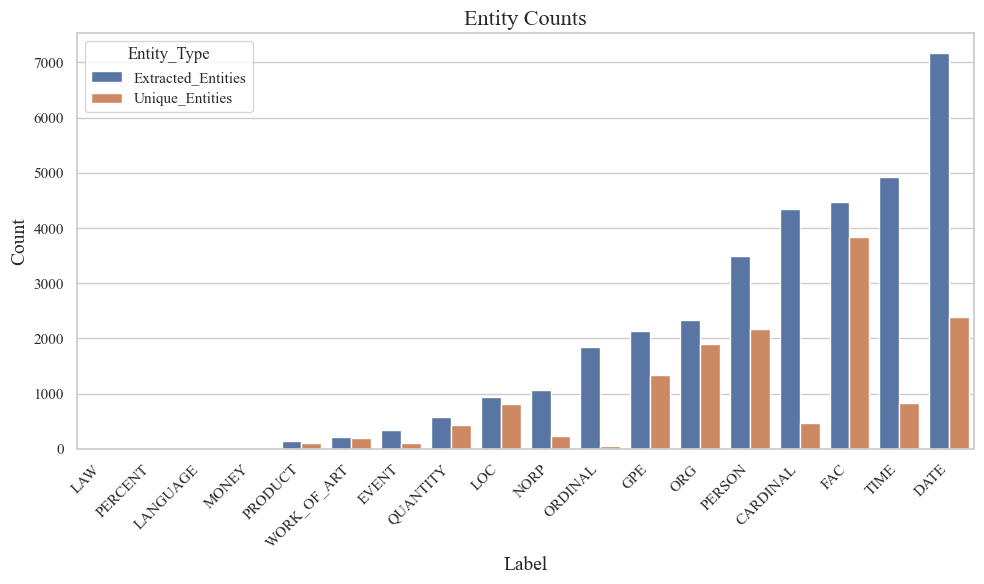

In [192]:
cols = ["Extracted_Entities", "Unique_Entities"]
idxs = dfTemp.index.to_list()
idxs.remove("Total") 

dfTemp

df_plot = (dfTemp.loc[idxs, cols]
           .sort_values(by = "Extracted_Entities", ascending = True)
           .reset_index()
           .melt(id_vars='index', value_vars=cols, var_name='Entity_Type', value_name='Count')
)

df_plot.rename(columns={'index': 'Label'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.set(style='whitegrid', font='Times New Roman')
sns.barplot(data=df_plot, x='Label', y='Count', hue='Entity_Type')


plt.title(f'Entity Counts', fontsize=16)
plt.xlabel('Label', fontsize = 14)
plt.ylabel('Count', fontsize = 14)
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

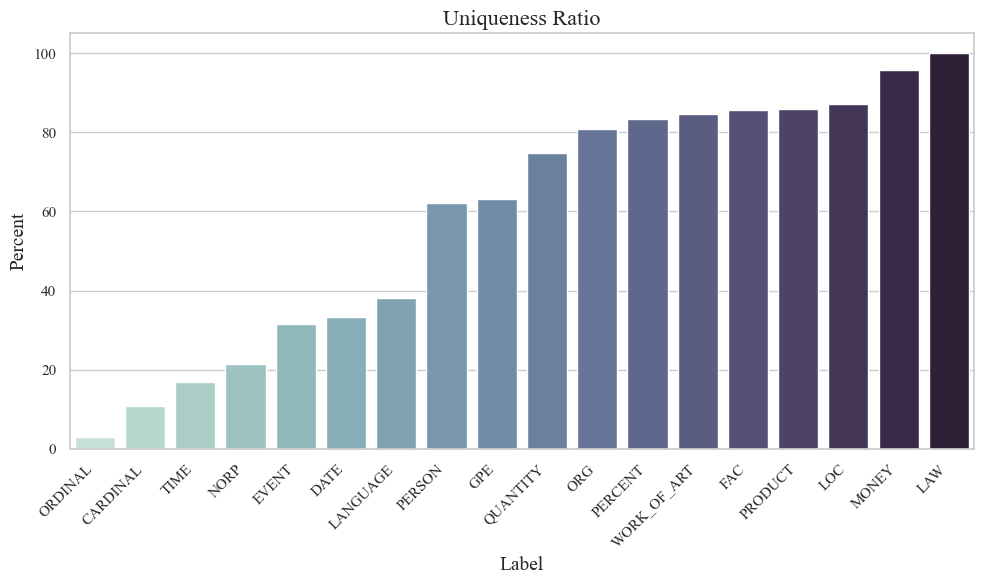

In [193]:
cols = ["%_Unique_Ratio"]
idxs = dfTemp.index.to_list()
idxs.remove("Total") 

dfTemp

df_plot = (dfTemp.loc[idxs, cols]
           .sort_values(by = "%_Unique_Ratio", ascending = True)
           .reset_index()
           .melt(id_vars='index', value_vars=cols, var_name='Entity_Type', value_name='Count')
)

df_plot.rename(columns={'index': 'Label'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.set(style='whitegrid', font='Times New Roman')
sns.barplot(data=df_plot, x='Label', y='Count', hue='Label', palette = "ch:s=.5,rot=-.5")


plt.title(f'Uniqueness Ratio', fontsize=16)
plt.xlabel('Label', fontsize = 14)
plt.ylabel('Percent', fontsize = 14)
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

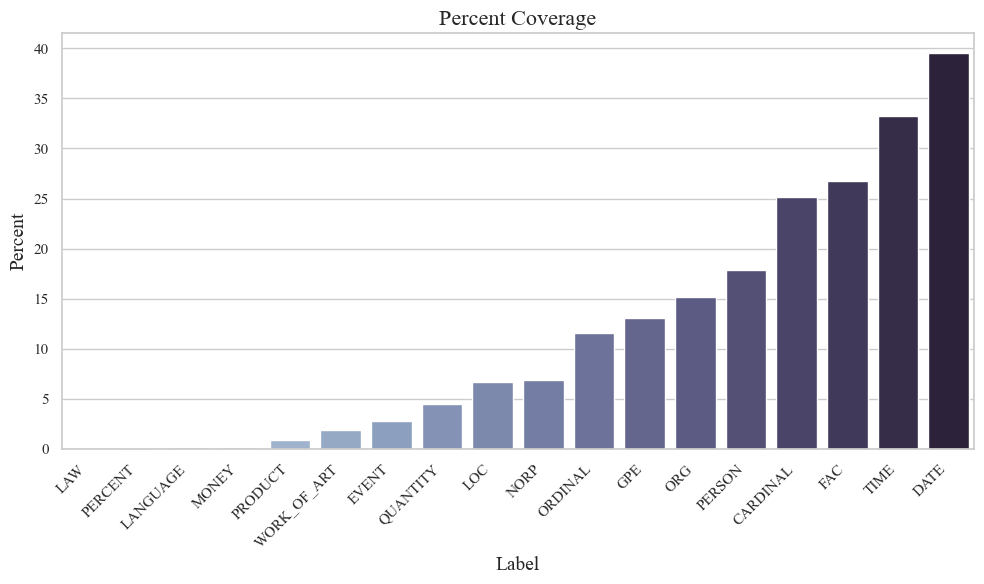

In [191]:
cols = ["%_Coverage"]
idxs = dfTemp.index.to_list()
idxs.remove("Total") 

dfTemp

df_plot = (dfTemp.loc[idxs, cols]
           .sort_values(by = "%_Coverage", ascending = True)
           .reset_index()
           .melt(id_vars='index', value_vars=cols, var_name='Entity_Type', value_name='Count')
)

df_plot.rename(columns={'index': 'Label'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.set(style='whitegrid', font='Times New Roman')
sns.barplot(data=df_plot, x='Label', y='Count', hue='Label', palette = "ch:s=.25,rot=-.25")


plt.title(f'Percent Coverage', fontsize=16)
plt.xlabel('Label', fontsize = 14)
plt.ylabel('Percent', fontsize = 14)
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

- Most unique entity type is FAC with 3,836 different entities identifies. 
    - Most unique are locations, FACs, and works of art
    - Least unique are ordinals, cardinals, and times
- There were two laws extracted
    - index 2158 : "ACT III"
    - index 2806 : "Yearbook/Newspaper"

In [146]:
label = "LAW"
rows_with_entity = df["Named_Entities"].apply(lambda row : any(map(lambda x: x[1] == label, row) if isinstance(row, list) else False))
df.loc[rows_with_entity]

,City,Country,Description,Location,State,State_Abbrev,Longitude,Latitude,City_Longitude,City_Latitude,...,Distance_to_Nearest_Worship,Religion_Intersection,Daylight_Duration_Hours,GeoTopic_Name,GeoTopic_Latitude,GeoTopic_Longitude,Named_Entities,Image_Pointer,Image_Caption,Image_Objects
Haunted_Places_Id,,,,,,,,,,,,,,,,,,,,,
2158,Beaverton,United States,A shadowy figure has been reported lurking in ...,Westgate Cinema,Oregon,OR,-122.812048,45.497790,-122.803710,45.487062,...,2196.31,christian,9.015,NaN,NaN,NaN,"[(June 2005, DATE), (Act III, LAW), (a couple ...",NaN,NaN,NaN
2806,Los Angeles,United States,The Cold spots near the senior patio. In the Y...,Cathedral High School,California,CA,-118.234596,34.069826,-118.243685,34.052234,...,1017.16,christian,9.981,NaN,NaN,NaN,"[(Yearbook/Newspaper, LAW)]",NaN,NaN,NaN


In [ ]:
highest_coverage = dfTemp.nlargest(10, "%_Coverage")
highest_coverage


In [ ]:
#########################################################
## Columns ##
cols = dfTemp.columns.tolist()
## Rows ##
rows = [[total_unique_entities, total_extracted_entities], # Total
                                                           # Percent Coverage
        ]
## Table settings ##
column_width = 25
table_length = column_width * len(cols)
header = '|'.join(f'{col:^{column_width}}' for col in cols)

# r1 = '|'.join(f'{x:^{column_width}}' for x in num_unique_entities)
# r2 = '|'.join(f'{x:^{column_width}}' for x in num_unique_entities)

# Top of table and columns
print("-" * table_length)
print(f"SpaCY Performance Summary".center(round(table_length)))
print("-" * table_length)
print('|' + header + '|')
print("-" * table_length)
for row in rows:
    row = '|'.join(f'{x:^{column_width}}' for x in row)
    print('|' + row + '|')
print("-" * table_length)

print("Number of unique entities: ", sum(num_unique_entities))
print("Number of total entities: ", sum(num_total_entities))

print()

--------------------------------------------------
            SpaCY Performance Summary             
--------------------------------------------------
|     Unique_Entities     |   Extracted_Entities    |
--------------------------------------------------
|          14921          |          34044          |
--------------------------------------------------
Number of unique entities:  14921
Number of total entities:  34044



### Date and Time Analysis

How do **"TIME"** and **"Date"** entities improve upon our existing **"Time_of_Day"** and **"Haunted_Places_Date"** features? 

#### **"Haunted_Places_Date"**




In [ ]:
ent_counts = get_ent_counts(df["Named_Entities"].values, ner_labels)

In [33]:
ent_counts = get_ent_counts(df["Named_Entities"].values, ner_labels)

label = "DATE"

print("-" * 75)
print(f"Summary for {label}:".center(78))
print("-" * 75)

print(f"Extracted entities: {sum(ent_counts[label].values())}")
print(f"Unique extracted entities: {len(ent_counts[label].keys())}")



---------------------------------------------------------------------------
                              Summary for DATE:                               
---------------------------------------------------------------------------
Extracted entities: 7168
Unique extracted entities: 2385


In [30]:

n = 100
res = get_top_ent_counts(ent_counts, "DATE", n = n)
total_parsed = 0

# Top of table and columns
print("-" * 75)
print(f"Top {n} counts for {label}:".center(78))
print("-" * 75)
print(f'| {"Entity":^25}|{"Count":^25}|{"Parsed Dates":^25}|')

# loop through top counts
for ent, count in res:
    
    # Check if date is parsable by extract_dates function from assignment 1:
    parsed_dates = []
    for val in extract_dates(ent).values():
        if isinstance(val, list):
            [parsed_dates.append(v) for v in val if v != datetime.date(2025, 1, 1)]
    
    # If parsed_dates is not empty. We parsed the correct date. Increment count

    if len(parsed_dates) != 0:
        total_parsed += 1
    clean_dates(parsed_dates)
    # |print entity | count | parsed dates|
    print(f'| {ent:^25}|{count:^25}|{str(parsed_dates).replace("datetime.date",""):^25}|')
print("-" * 75)

# Total coverage of parser from A1
total_ner = sum(map(lambda x: x[1], ent_counts['DATE'].most_common(100)))
total_coverage = (total_parsed / n) * 100 

print(f"Of the top 100 {label} entities, our previous method parsed : {total_coverage:2g}%")
print("-" * 75)


---------------------------------------------------------------------------
                           Top 100 counts for DATE:                           
---------------------------------------------------------------------------
|          Entity          |          Count          |      Parsed Dates       |
|         this day         |           169           |           []            |
|           today          |           115           |           []            |
|           years          |           113           |           []            |
|         the years        |           110           |           []            |
|          the day         |           102           |           []            |
|     the early 1900's     |           96            |     [(1900, 1, 1)]      |
|         years ago        |           87            |           []            |
|      many years ago      |           86            |           []            |
|        many years        |           8

### Time Analysis

How do **"TIME"** and **"Date"** entities improve upon our existing **"Time_of_Day"** and **"Haunted_Places_Date"** features? improve our knowledge of "TIME"  does "TIME" and "Date" 
